In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean

styles = {
    'AE': {'line': 'darkred', 'fill': 'red'},
    'CE': {'line': 'navy',    'fill': 'blue'}
}


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125468,2937,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,0.978558,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752304,4.278123
125469,2937,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,0.972594,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165623,28.370419
125470,2937,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,0.949624,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
125471,2937,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,0.937880,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [4]:
def panel(ax, xcol, xlabel, legend_key, xlim=None, split=None, reg_lo_override=None,
          reg_hi_override=None, scatter=False, xlim_flag=False, ncol=2, df_data=df_eddies, zonal_TD=False, meridional_TD=False):
    df_all = df_data.dropna(subset=[xcol])
    x_min, x_max = df_all[xcol].min(), df_all[xcol].max()

    nbins = 30
    bins = np.unique(np.quantile(df_all[xcol], np.linspace(0, 1, nbins + 1)))
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        if zonal_TD:
            dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis_x'])
        elif meridional_TD:
            dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis_y'])
        else:
            dfm = df_data[df_data.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])
        if len(dfm) == 0:
            continue
        xval = dfm[xcol].values
        if zonal_TD:
            tilt = dfm['TiltDis_x'].values
        elif meridional_TD:
            tilt = dfm['TiltDis_y'].values
        else:
            tilt = dfm['TiltDis'].values

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)
        med = [np.nanmedian(tilt[d == i]) for i in range(1, len(bins))]
        q25 = [np.nanquantile(tilt[d == i], .25) for i in range(1, len(bins))]
        q75 = [np.nanquantile(tilt[d == i], .75) for i in range(1, len(bins))]

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        ax.plot(bin_centers, med, lw=3, color=styles[cyc]['line'], alpha=.6)
        ax.fill_between(bin_centers, q25, q75, color=styles[cyc]['fill'], alpha=0.10)

        if split is None:
            lo, hi = np.nanpercentile(xval, [10, 90])
            mask = (xval >= lo) & (xval <= hi)
            m, c, *_ = linregress(xval[mask], tilt[mask])
            xf = np.linspace(lo, hi, 200)
            ax.plot(
                xf, m*xf + c, '--', lw=3, color=styles[cyc]['fill'],
                label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c<0 else "$+$"} {abs(c):.3g}'
            )
        else:
            lo, hi = np.nanpercentile(xval, [10, 90])

            hi2 = reg_hi_override if reg_hi_override is not None else hi
            lo2 = reg_lo_override if reg_lo_override is not None else lo

            for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                mask = (xval >= a) & (xval <= b)
                if mask.sum() > 2:
                    m, c, *_ = linregress(xval[mask], tilt[mask])
                    xf = np.linspace(a, b, 200)
                    ax.plot(
                        xf, m*xf + c,
                        ':' if l == 0 else '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c<0 else "$+$"} {abs(c):.3g}'
                    )

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_data[xcol], [10, 90]))
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())

    ax.legend(loc='upper left', ncol=ncol)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

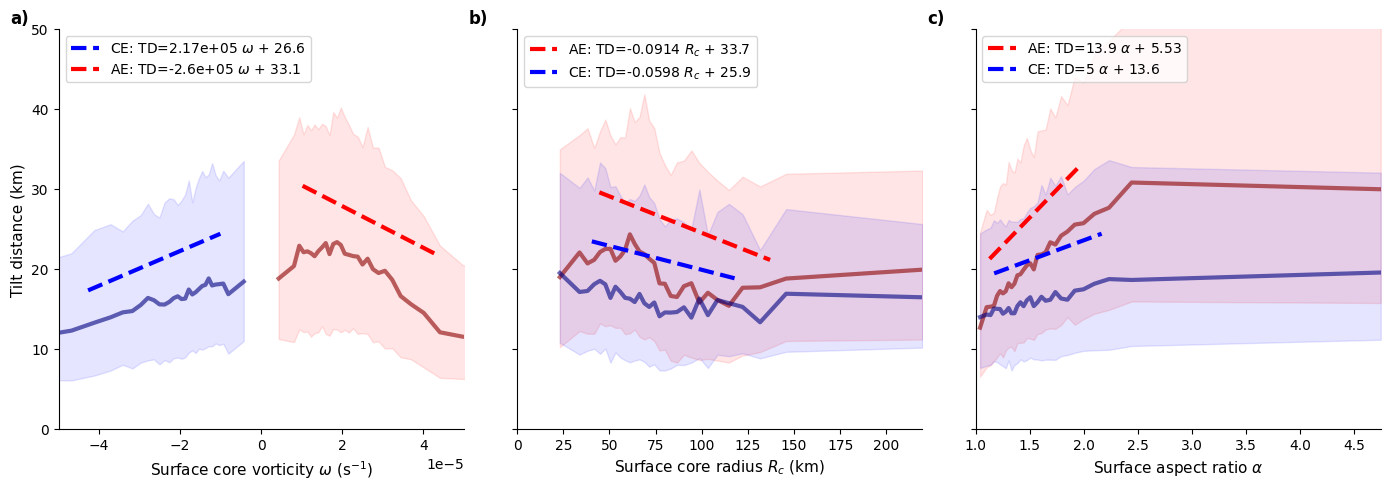

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True, constrained_layout=False)

panel(
    axs[0],
    'w',
    r'',
    r'$\omega$',
    xlim_flag=False,
    scatter=False,
    xlim=(-4e-5, 4e-5),
    ncol=1,
    df_data=df_eddies[df_eddies.Cyc=='CE'].copy()
)
panel(
    axs[0],
    'w',
    r'Surface core vorticity $\omega$ (s$^{-1}$)',
    r'$\omega$',
    xlim_flag=False,
    scatter=False,
    xlim=(-5e-5, 5e-5),
    ncol=1,
    df_data=df_eddies[df_eddies.Cyc=='AE'].copy()
)
axs[0].set_ylabel('Tilt distance (km)', fontsize=11)
axs[0].text(-0.12, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

panel(
    axs[1],
    'Rc',
    'Surface core radius $R_c$ (km)',
    r'$R_c$',
    xlim_flag=True,
    scatter=False,
    # xlim=(40, 160),
    ncol=1
)
axs[1].text(-0.12, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].set_xlim(0, None)

panel(
    axs[2],
    'AR',
    r'Surface aspect ratio $\alpha$',
    r'$\alpha$',
    xlim_flag=True,
    scatter=False,
    # xlim=(1, 2.5),
    ncol=1
)
axs[2].text(-0.12, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[2].set_ylim(0, 50)
axs[2].set_xlim(1, None)
plt.tight_layout()
plt.show()


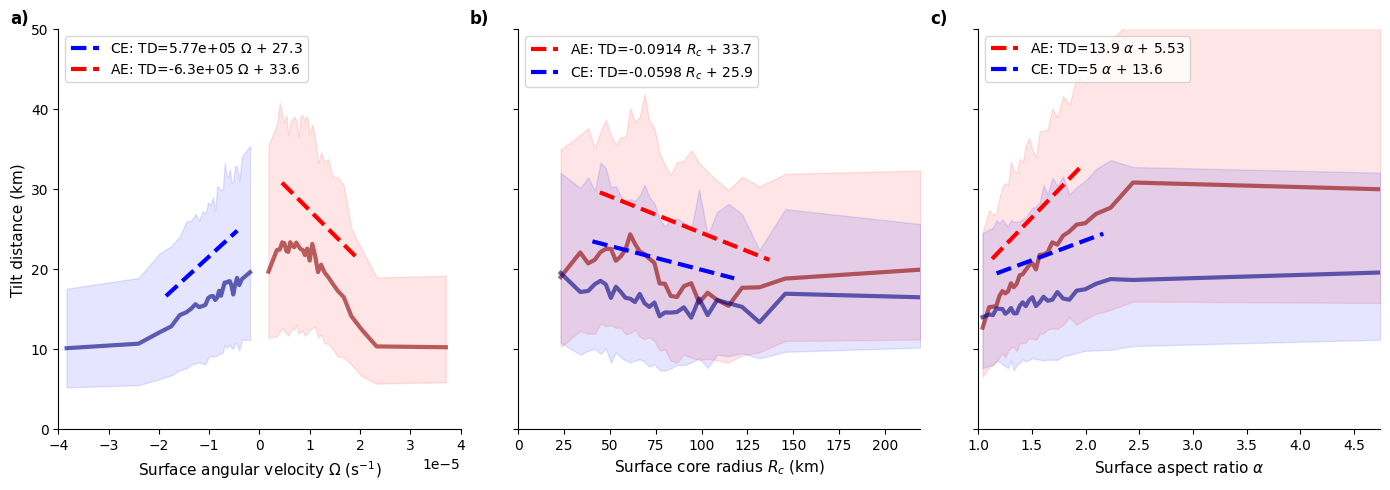

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True, constrained_layout=False)

panel(
    axs[0],
    'Omega',
    '',
    r'$\Omega$',
    xlim_flag=False,
    scatter=False,
    xlim=(-4e-5, 4e-5),
    ncol=1,
    df_data=df_eddies[df_eddies.Cyc=='CE'].copy()
)
panel(
    axs[0],
    'Omega',
    r'Surface angular velocity $\Omega$ (s$^{-1}$)',
    r'$\Omega$',
    xlim_flag=False,
    scatter=False,
    xlim=(-4e-5, 4e-5),
    ncol=1,
    df_data=df_eddies[df_eddies.Cyc=='AE'].copy()
)
axs[0].set_ylabel('Tilt distance (km)', fontsize=11)
axs[0].text(-0.12, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

panel(
    axs[1],
    'Rc',
    'Surface core radius $R_c$ (km)',
    r'$R_c$',
    xlim_flag=True,
    scatter=False,
    # xlim=(40, 160),
    ncol=1
)
axs[1].text(-0.12, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].set_xlim(0, None)

panel(
    axs[2],
    'AR',
    r'Surface aspect ratio $\alpha$',
    r'$\alpha$',
    xlim_flag=True,
    scatter=False,
    # xlim=(1, 2.5),
    ncol=1
)
axs[2].text(-0.12, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[2].set_ylim(0, 50)
axs[2].set_xlim(1, None)
plt.tight_layout()
plt.show()

In [7]:
# Nbar
df_eddies = compute_core_mean(
    df_eddies,
    X_grid, Y_grid,
    mask_rho,
    base_path="/srv/scratch/z5297792/Climatology/N2s/Nbars_300m_depth",
    varname="Nbar",
    colname="Nbar"
)


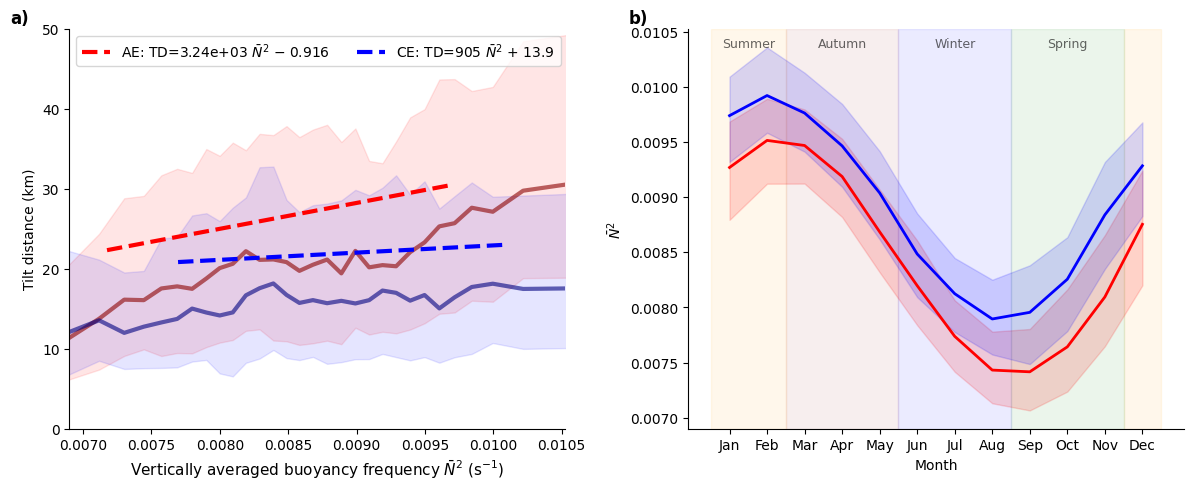

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# LEFT: PANEL (Nbar vs Tilt)
# -------------------
panel(
    axs[0],
    'Nbar',
    r'Vertically averaged buoyancy frequency $\bar{N}^2$ (s$^{-1}$)',
    r'$\bar{N}^2$',
    xlim_flag=False,
    scatter=False,
    xlim=(.007, .0105),
    ncol=2,
    df_data=df_eddies
)
axs[0].set_ylabel('Tilt distance (km)')
axs[0].set_ylim(0, 50)


# -------------------
# RIGHT: MONTHLY PANEL
# -------------------
df_AE = df_eddies[df_eddies.Cyc == 'AE'].copy()
df_CE = df_eddies[df_eddies.Cyc == 'CE'].copy()

for label, df, c in [('AE', df_AE, 'r'), ('CE', df_CE, 'b')]:
    df_ = df.copy()
    df_['Month'] = df_.Date.dt.month

    g = df_.groupby('Month').Nbar
    med = g.median()
    q25 = g.quantile(0.25)
    q75 = g.quantile(0.75)

    axs[1].plot(med.index, med.values, lw=2, color=c, label=label)
    axs[1].fill_between(med.index, q25, q75, color=c, alpha=0.15)

# -------------------
# SEASON SHADING
# -------------------
season_spans = [
    (12-0.5, 12.5, 'Summer'),   # Dec (wrap handled below)
    (0.5, 2.5, 'Summer'),       # Jan–Feb
    (2.5, 5.5, 'Autumn'),
    (5.5, 8.5, 'Winter'),
    (8.5, 11.5, 'Spring')
]

season_colors = {
    'Summer': 'orange',
    'Autumn': 'brown',
    'Winter': 'blue',
    'Spring': 'green'
}

for start, end, season in season_spans:
    axs[1].axvspan(start, end, color=season_colors[season], alpha=0.08, zorder=-1)

season_centers = {
    'Summer': 1.5,
    'Autumn': 4,
    'Winter': 7,
    'Spring': 10
}

for s, x in season_centers.items():
    axs[1].text(x, 0.01045, s,
                ha='center', va='top', fontsize=9, alpha=0.6)

axs[1].set_xticks(range(1, 13))
axs[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
axs[1].set_xlabel('Month')
axs[1].set_ylabel(r'$\bar{N}^2$')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[0].text(-0.12, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].text(-0.12, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

axs[0].set_xlim(axs[1].get_ylim())

plt.subplots_adjust(wspace=0.001)
plt.tight_layout()
